# So Sánh Hiệu Năng: Bicubic - SRCNN RTL (Q7) - Swift-SRGAN (Q7)

**So sánh 3 Mô hình / Phương pháp:**
1. **Bicubic (Baseline):** Thuật toán nội suy kinh điển đo đạc trên phần cứng.
2. **SRCNN RTL (Q7) (Mô hình chính của đề tài):** Mạng nơ-ron tích chập kiến trúc RTL tối ưu hóa triển khai trên FPGA (lượng tử hóa Q7 INT8).
3. **Swift-SRGAN (Q7):** Mạng GAN rút gọn kênh (Depthwise Separable Convolutions, lượng tử hóa Q7 INT8) tối ưu hóa phần cứng FPGA (được đánh giá tại tỉ lệ Scale 4x).

- **2 Datasets:** `sub_NIH` (1,750 ảnh) | `sub_chest` (450 ảnh)
- **3 Scales:** 2× | 3× | 4× *(Lưu ý: Swift-SRGAN Q7 trên phần cứng FPGA chỉ thiết kế và đánh giá cho Scale 4x; tại Scale 2× và 3× hiển thị `—`)*.
- **Báo cáo phân chia theo cấu trúc phân cấp:**
  - **Mục I. Tập dữ liệu sub_NIH** (Scale 2x, 3x, 4x)
  - **Mục II. Tập dữ liệu sub_chest** (Scale 2x, 3x, 4x)


In [1]:
import json, os, numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
from pathlib import Path

# ── Style constants ───────────────────────────────────────────
HEADER_BG   = '#1a3a5c'
HEADER_FG   = 'white'
ROW_ODD     = '#eaf1fb'
ROW_EVEN    = '#ffffff'
PENDING_BG  = '#fff9e6'
PENDING_FG  = '#b07700'
EDGE_COLOR  = '#c8d4e3'
PAGE_BG     = '#f5f8fc'
TITLE_COLOR = '#1a3a5c'
SUB_COLOR   = '#555555'

METRICS = ['PSNR', 'SSIM', 'MS_SSIM', 'LPIPS', 'NIQE', 'EPI', 'MSE', 'RMSE', 'Latency', 'FPS']
METRIC_LABELS = [
    'PSNR (dB) ↑', 'SSIM ↑', 'MS-SSIM ↑', 'LPIPS ↓',
    'NIQE ↓', 'EPI ↑', 'MSE ↓', 'RMSE ↓', 'Latency (ms) ↓', 'Tốc độ (FPS) ↑'
]
PENDING_MODELS = set()

BASE = Path(__file__).resolve().parent.parent.parent if '__file__' in dir() else Path.cwd()
# Detect project root
for p in [Path('.'), Path('..'), Path('../..')]:
    if (p / 'results').exists():
        BASE = p.resolve()
        break

def fmt_val(metric, v):
    if v is None: return '—'
    try:
        f = float(v)
        if metric == 'PSNR':
            return f"{f:.4f} dB"
        elif metric == 'Latency':
            return f"{f:.2f} ms"
        elif metric == 'FPS':
            return f"{f:.1f} FPS"
        return f"{f:.4f}"
    except:
        return str(v)

def load_bicubic(scale):
    fn = BASE / f'results/hardware/bicubic_{scale}x_benchmark.json'
    with open(fn) as f: d = json.load(f)
    out = {}
    for ds in ['sub_NIH', 'sub_chest']:
        recs = [r for r in d['per_image_results'] if r.get('dataset') == ds and r['status'] == 'ok']
        lat = np.mean([r['latency_ms'] for r in recs])
        out[ds] = {
            'N': len(recs),
            'PSNR':     round(float(np.mean([r['psnr_bicubic_db'] for r in recs])), 4),
            'SSIM':     round(float(np.mean([r['ssim_bicubic'] for r in recs])), 4),
            'MS_SSIM':  round(float(np.mean([r['ms_ssim_bicubic'] for r in recs])), 4),
            'LPIPS':    round(float(np.mean([r['lpips_bicubic'] for r in recs])), 4),
            'NIQE':     round(float(np.mean([r['niqe_bicubic'] for r in recs])), 4),
            'EPI':      round(float(np.mean([r['epi_bicubic'] for r in recs])), 4),
            'MSE':      round(float(np.mean([r['mse_bicubic'] for r in recs])), 4),
            'RMSE':     round(float(np.mean([r['rmse_bicubic'] for r in recs])), 4),
            'Latency':  round(float(lat), 2),
            'FPS':      round(1000/float(lat), 1),
        }
    return out

def load_software(model, scale):
    fn = BASE / f'results/software/{model.upper()}/{model.lower()}_{scale}x_benchmark.json'
    if not fn.exists(): return None
    with open(fn) as f: d = json.load(f)
    out = {}
    for ds in ['sub_NIH', 'sub_chest']:
        recs = [r for r in d['per_image_results'] if r.get('dataset') == ds and r['status'] == 'ok']
        if not recs: out[ds] = None; continue
        lat = np.mean([r['latency_ms'] for r in recs if r.get('latency_ms') is not None])
        
        def val(r, *keys):
            for k in keys:
                v = r.get(k)
                if v is not None:
                    return float(v)
            return 0.0

        out[ds] = {
            'N': len(recs),
            'PSNR':    round(float(np.mean([val(r, 'psnr_model_db', 'psnr_fpga_db') for r in recs])), 4),
            'SSIM':    round(float(np.mean([val(r, 'ssim_model', 'ssim_fpga') for r in recs])), 4),
            'MS_SSIM': round(float(np.mean([val(r, 'msssim_fpga', 'msssim_model') for r in recs])), 4),
            'LPIPS':   round(float(np.mean([val(r, 'lpips_fpga', 'lpips_srgan', 'lpips') for r in recs])), 4),
            'NIQE':    round(float(np.mean([val(r, 'niqe_fpga', 'niqe_model') for r in recs])), 4),
            'EPI':     round(float(np.mean([val(r, 'epi') for r in recs])), 4),
            'MSE':     round(float(np.mean([val(r, 'mse_model', 'mse_fpga') for r in recs])), 4),
            'RMSE':    round(float(np.mean([val(r, 'rmse_model', 'rmse_fpga') for r in recs])), 4),
            'Latency': round(float(lat), 2),
            'FPS':     round(1000/float(lat), 1) if lat > 0 else 0.0,
        }
    return out

def load_swift_srgan(scale):
    """Load kết quả benchmark Swift-SRGAN (Q7) tối ưu hóa phần cứng FPGA (chỉ có Scale 4x)."""
    if scale != 4:
        return {'sub_NIH': None, 'sub_chest': None}
    
    candidates = [
        BASE / 'results/hardware/swift_srgan_benchmark_q7.json',
        Path(os.path.expanduser('~/Downloads/swift_srgan_benchmark_q7.json')),
        Path('/Users/giabao/Downloads/split_benchmark_results/swift_srgan_sub_NIH.json'),
    ]
    fn = None
    for c in candidates:
        if c.exists():
            fn = c
            break
    if not fn:
        return {'sub_NIH': None, 'sub_chest': None}

    with open(fn, 'r', encoding='utf-8') as f:
        d = json.load(f)
    recs_all = d.get('per_image_results', [])
    out = {}
    for ds in ['sub_NIH', 'sub_chest']:
        recs = [r for r in recs_all if r.get('dataset') == ds and r.get('status', 'ok') == 'ok']
        if not recs:
            out[ds] = None
            continue
        lat = np.mean([r['latency_ms'] for r in recs if r.get('latency_ms') is not None])
        def val(r, *keys):
            for k in keys:
                v = r.get(k)
                if v is not None:
                    return float(v)
            return 0.0

        out[ds] = {
            'N': len(recs),
            'PSNR':    round(float(np.mean([val(r, 'psnr_fpga_db', 'psnr_model_db') for r in recs])), 4),
            'SSIM':    round(float(np.mean([val(r, 'ssim_fpga', 'ssim_model') for r in recs])), 4),
            'MS_SSIM': round(float(np.mean([val(r, 'msssim_fpga', 'ms_ssim_fpga') for r in recs])), 4),
            'LPIPS':   round(float(np.mean([val(r, 'lpips', 'lpips_srgan', 'lpips_fpga') for r in recs])), 4),
            'NIQE':    round(float(np.mean([val(r, 'niqe_fpga', 'niqe_model') for r in recs])), 4),
            'EPI':     round(float(np.mean([val(r, 'epi') for r in recs])), 4),
            'MSE':     round(float(np.mean([val(r, 'mse_fpga', 'mse_model') for r in recs])), 4),
            'RMSE':    round(float(np.mean([val(r, 'rmse_fpga', 'rmse_model') for r in recs])), 4),
            'Latency': round(float(lat), 2),
            'FPS':     round(1000/float(lat), 1) if lat > 0 else 0.0,
        }
    return out

def build_transposed_table(models, model_data_dict, ds):
    col_labels = ['Thông số'] + models
    table_rows = []
    for m_key, m_label in zip(METRICS, METRIC_LABELS):
        row = [m_label]
        for model in models:
            m_source = model_data_dict.get(model)
            data = m_source.get(ds) if m_source else None
            v = data.get(m_key) if data else None
            row.append(fmt_val(m_key, v))
        table_rows.append(row)
    return col_labels, table_rows

def render_table(title, subtitle, col_labels, table_rows, out_path, pending_models=None):
    if pending_models is None: pending_models = PENDING_MODELS
    models = col_labels[1:]
    col_w = [0.20, 0.22, 0.28, 0.30]
    fig_w = 10.5
    fig_h = 7.5
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    fig.patch.set_facecolor(PAGE_BG)
    ax.set_facecolor(PAGE_BG)
    ax.axis('off')

    # Title & Subtitle (Hierarchical sections)
    if subtitle:
        fig.text(0.5, 0.965, title, ha='center', va='top',
                 fontsize=12.5, fontweight='bold', color=TITLE_COLOR,
                 fontfamily='DejaVu Sans')
        fig.text(0.5, 0.925, subtitle, ha='center', va='top',
                 fontsize=11.0, fontweight='bold', color='#2b6cb0',
                 fontfamily='DejaVu Sans')
    else:
        fig.text(0.5, 0.94, title, ha='center', va='top',
                 fontsize=13.0, fontweight='bold', color=TITLE_COLOR,
                 fontfamily='DejaVu Sans')
    def parse_float(v_str):
        try:
            return float(v_str.replace('dB', '').replace('ms', '').replace('FPS', '').strip())
        except:
            return None

    best_cols_per_row = {}
    for r_idx, row in enumerate(table_rows, start=1):
        label = row[0]
        is_higher = '↑' in label
        valid_items = []
        for c_idx, val_str in enumerate(row[1:], start=1):
            m_name = models[c_idx - 1] if c_idx - 1 < len(models) else ''
            if m_name in pending_models:
                continue
            v_num = parse_float(val_str)
            if v_num is not None:
                valid_items.append((c_idx, v_num))
        if valid_items:
            best_v = max(v for _, v in valid_items) if is_higher else min(v for _, v in valid_items)
            best_cols_per_row[r_idx] = [c for c, v in valid_items if np.isclose(v, best_v)]
        else:
            best_cols_per_row[r_idx] = []

    tbl = ax.table(cellText=table_rows, colLabels=col_labels, colWidths=col_w,
                   loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1, 1.85)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor(EDGE_COLOR)
        cell.set_linewidth(0.5)
        if r == 0:
            cell.set_facecolor(HEADER_BG)
            cell.set_text_props(color=HEADER_FG, fontweight='bold', fontsize=10)
        else:
            if c == 0:
                cell.set_facecolor('#e2eaf4')
                cell.set_text_props(fontweight='bold', color='#1a3a5c')
            else:
                model_name = models[c-1] if c-1 < len(models) else ''
                if model_name in pending_models:
                    cell.set_facecolor(PENDING_BG)
                    cell.set_text_props(color=PENDING_FG)
                else:
                    is_best = (c in best_cols_per_row.get(r, []))
                    if is_best:
                        cell.set_text_props(fontweight='bold', color='#0f2b48')
                        cell.set_facecolor('#dce9f8' if r % 2 == 1 else '#eef5fd')
                    elif r % 2 == 1:
                        cell.set_facecolor(ROW_ODD)
                    else:
                        cell.set_facecolor(ROW_EVEN)

    # Chú thích ở góc dưới
    if 'Swift-SRGAN (Q7)' in pending_models:
        note_q7 = "\n   * Màu vàng (—): Swift-SRGAN Q7 trên phần cứng FPGA chỉ thiết kế và đánh giá cho Scale 4x"
    else:
        note_q7 = "\n   In đậm: Chỉ số tốt nhất giữa các mô hình  |  SRCNN RTL (Q7) & Swift-SRGAN (Q7): Kiến trúc tối ưu hóa phần cứng FPGA"
    note_text = (
        "* Ghi chú:  (↑) Giá trị càng cao càng tốt  |  (↓) Giá trị càng thấp càng tốt"
        f"{note_q7}"
    )
    fig.text(0.04, 0.025, note_text, ha='left', va='bottom',
             fontsize=9.0, color='#555555', style='italic', fontfamily='DejaVu Sans')

    plt.tight_layout(rect=[0, 0.06, 1, 0.90])
    plt.savefig(out_path, dpi=130, bbox_inches='tight', facecolor=PAGE_BG)
    plt.close()
    display(Image(out_path))
    print(f"  Saved: {out_path}")

# Create output directory
OUT_DIR = BASE / 'notebooks/analysis/output'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Setup hoàn tất. Thư mục output:", OUT_DIR)
print(f"✓ Project root: {BASE}")


✓ Setup hoàn tất. Thư mục output: /Users/giabao/Desktop/GitHub/AI-Based-Image-Super-Resolution/notebooks/analysis/output
✓ Project root: /Users/giabao/Desktop/GitHub/AI-Based-Image-Super-Resolution


## I. Tập dữ liệu sub_NIH


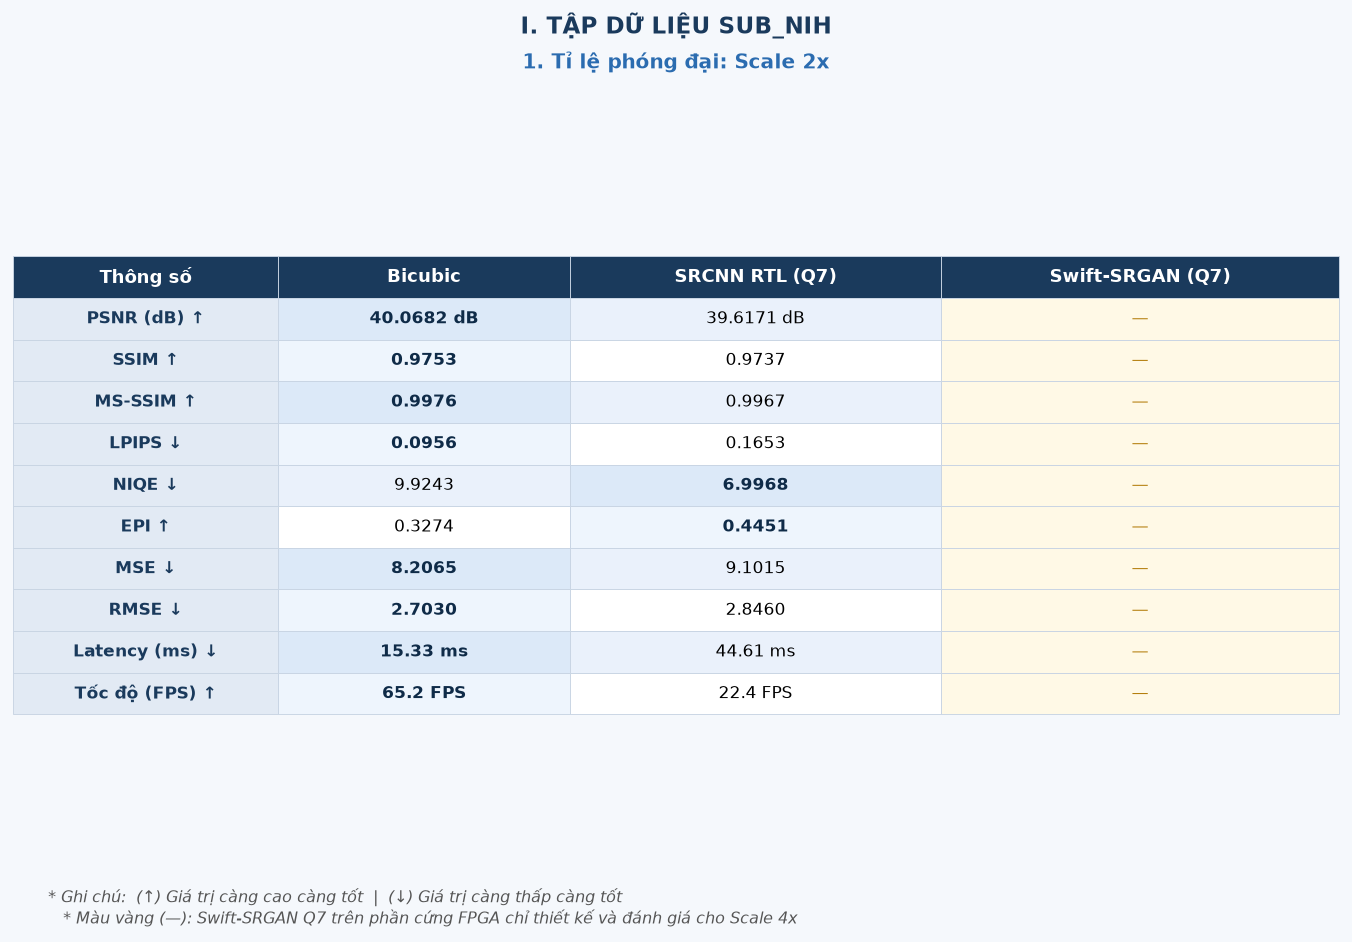

  Saved: /Users/giabao/Desktop/GitHub/AI-Based-Image-Super-Resolution/notebooks/analysis/output/nb2_sub_NIH_scale2x.png


In [2]:
# ── Mục I.1: sub_NIH | Scale 2x ──────────────────────────
scale = 2
ds    = 'sub_NIH'
ds_label = 'sub_NIH (1,750 ảnh)'

# Load data
model_data = {
    'Bicubic':          load_bicubic(scale),
    'SRCNN RTL (Q7)':   load_software('SRCNN', scale),
    'Swift-SRGAN (Q7)': load_swift_srgan(scale),
}

MODELS_NB2 = ['Bicubic', 'SRCNN RTL (Q7)', 'Swift-SRGAN (Q7)']
col_labels, rows = build_transposed_table(MODELS_NB2, model_data, ds)

title    = "I. TẬP DỮ LIỆU SUB_NIH"
subtitle = "1. Tỉ lệ phóng đại: Scale 2x"
out_png  = str(OUT_DIR / f"nb2_{ds}_scale2x.png")

render_table(title, subtitle, col_labels, rows, out_png, pending_models={'Swift-SRGAN (Q7)'})


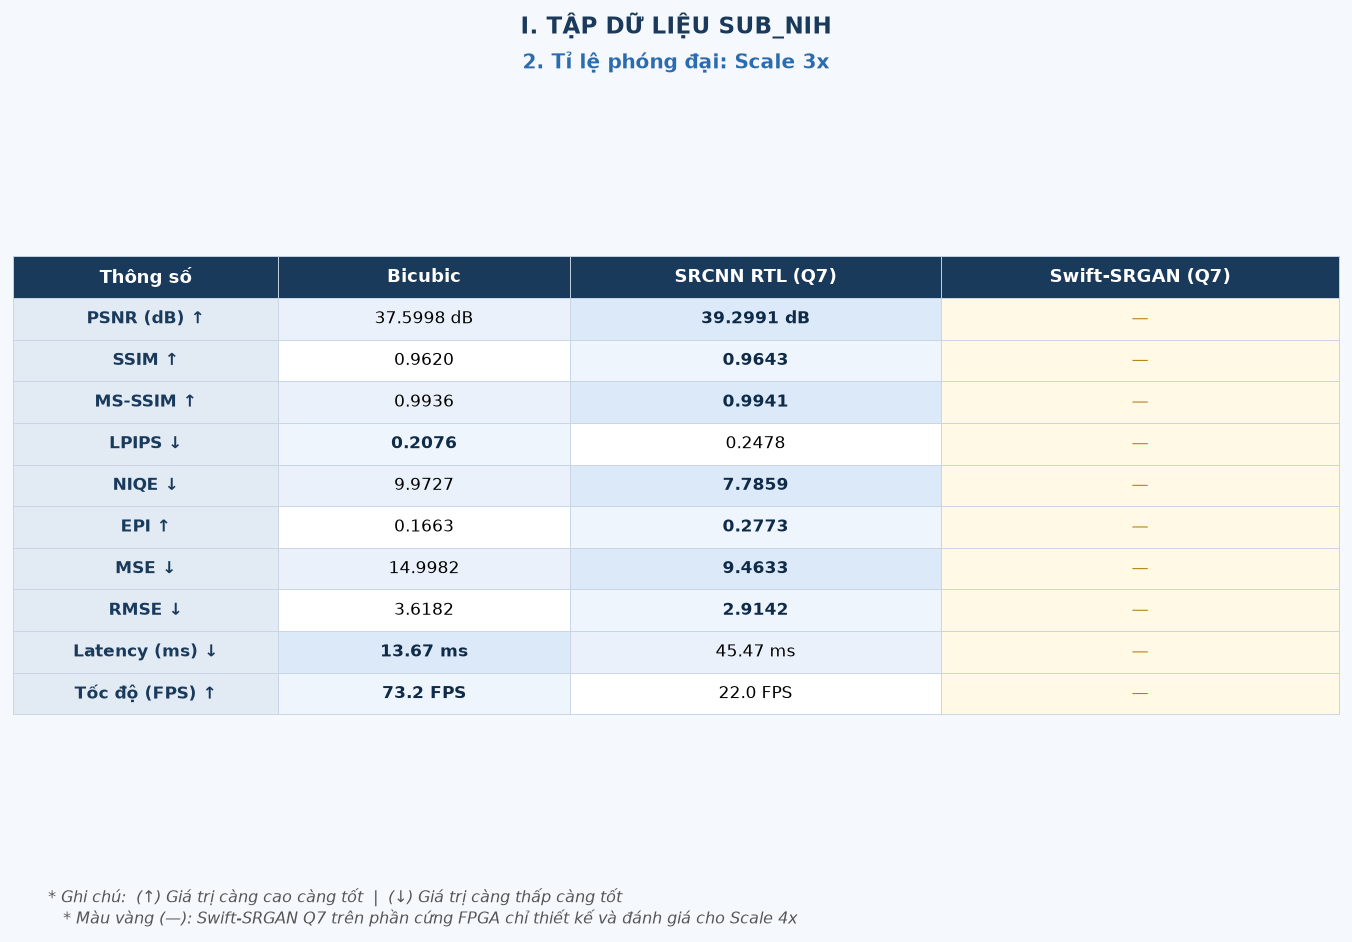

  Saved: /Users/giabao/Desktop/GitHub/AI-Based-Image-Super-Resolution/notebooks/analysis/output/nb2_sub_NIH_scale3x.png


In [3]:
# ── Mục I.2: sub_NIH | Scale 3x ──────────────────────────
scale = 3
ds    = 'sub_NIH'
ds_label = 'sub_NIH (1,750 ảnh)'

# Load data
model_data = {
    'Bicubic':          load_bicubic(scale),
    'SRCNN RTL (Q7)':   load_software('SRCNN', scale),
    'Swift-SRGAN (Q7)': load_swift_srgan(scale),
}

MODELS_NB2 = ['Bicubic', 'SRCNN RTL (Q7)', 'Swift-SRGAN (Q7)']
col_labels, rows = build_transposed_table(MODELS_NB2, model_data, ds)

title    = "I. TẬP DỮ LIỆU SUB_NIH"
subtitle = "2. Tỉ lệ phóng đại: Scale 3x"
out_png  = str(OUT_DIR / f"nb2_{ds}_scale3x.png")

render_table(title, subtitle, col_labels, rows, out_png, pending_models={'Swift-SRGAN (Q7)'})


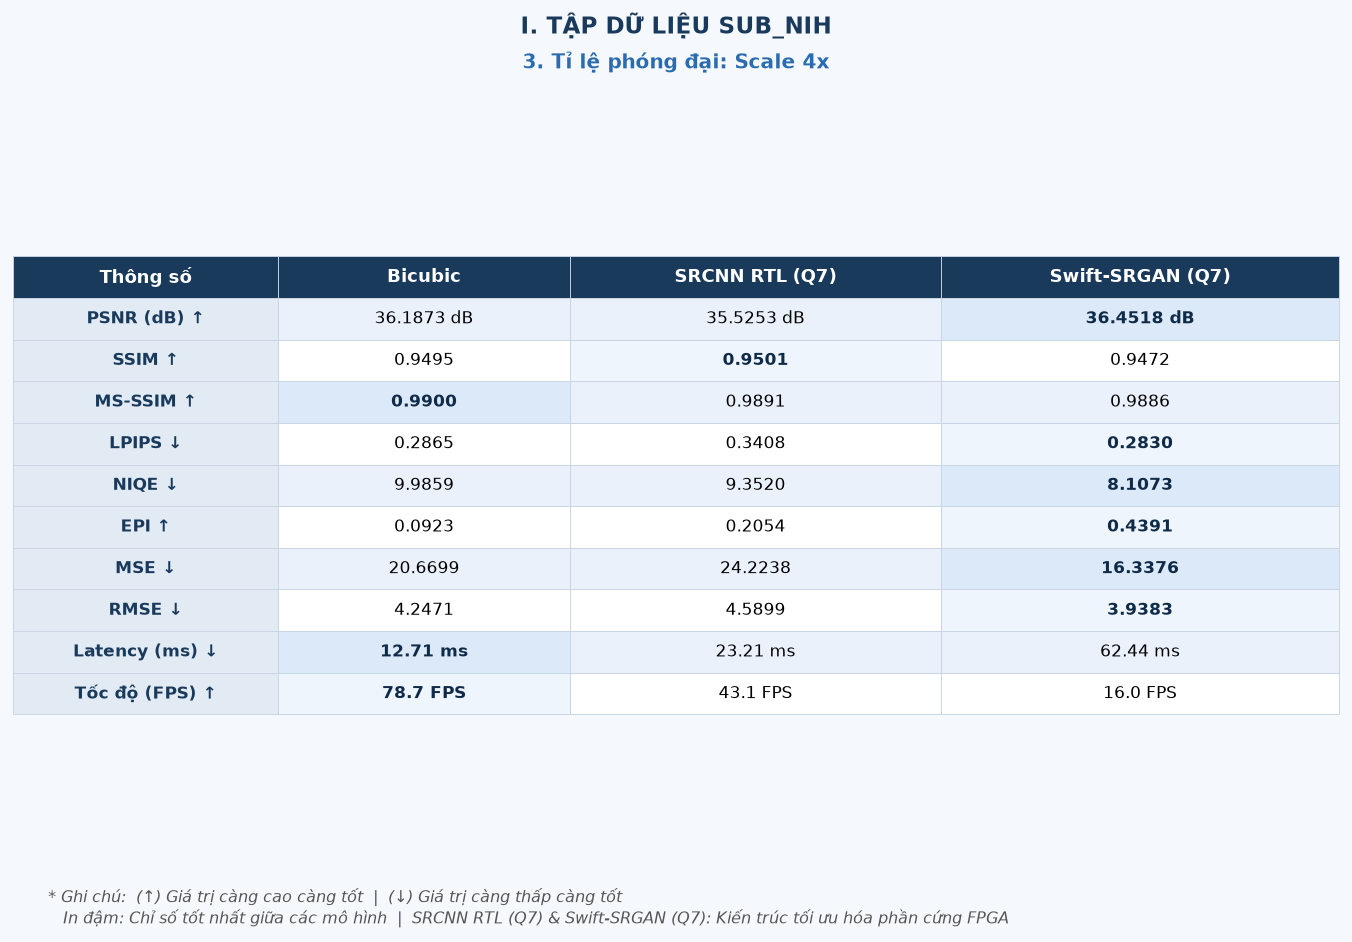

  Saved: /Users/giabao/Desktop/GitHub/AI-Based-Image-Super-Resolution/notebooks/analysis/output/nb2_sub_NIH_scale4x.png


In [4]:
# ── Mục I.3: sub_NIH | Scale 4x ──────────────────────────
scale = 4
ds    = 'sub_NIH'
ds_label = 'sub_NIH (1,750 ảnh)'

# Load data
model_data = {
    'Bicubic':          load_bicubic(scale),
    'SRCNN RTL (Q7)':   load_software('SRCNN', scale),
    'Swift-SRGAN (Q7)': load_swift_srgan(scale),
}

MODELS_NB2 = ['Bicubic', 'SRCNN RTL (Q7)', 'Swift-SRGAN (Q7)']
col_labels, rows = build_transposed_table(MODELS_NB2, model_data, ds)

title    = "I. TẬP DỮ LIỆU SUB_NIH"
subtitle = "3. Tỉ lệ phóng đại: Scale 4x"
out_png  = str(OUT_DIR / f"nb2_{ds}_scale4x.png")

render_table(title, subtitle, col_labels, rows, out_png, pending_models=set())


## II. Tập dữ liệu sub_chest


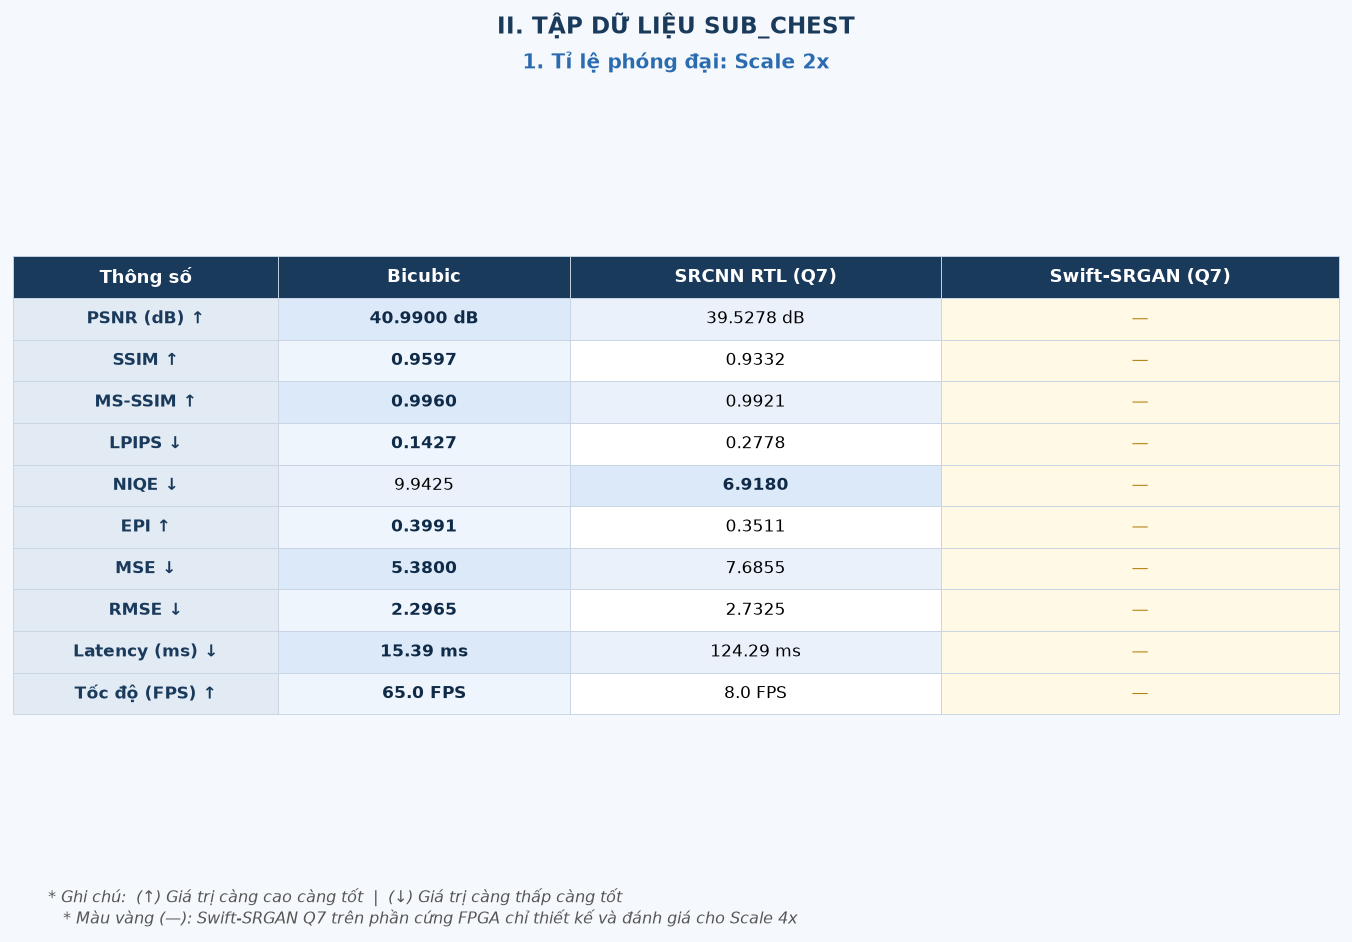

  Saved: /Users/giabao/Desktop/GitHub/AI-Based-Image-Super-Resolution/notebooks/analysis/output/nb2_sub_chest_scale2x.png


In [5]:
# ── Mục II.1: sub_chest | Scale 2x ──────────────────────────
scale = 2
ds    = 'sub_chest'
ds_label = 'sub_chest (450 ảnh)'

# Load data
model_data = {
    'Bicubic':          load_bicubic(scale),
    'SRCNN RTL (Q7)':   load_software('SRCNN', scale),
    'Swift-SRGAN (Q7)': load_swift_srgan(scale),
}

MODELS_NB2 = ['Bicubic', 'SRCNN RTL (Q7)', 'Swift-SRGAN (Q7)']
col_labels, rows = build_transposed_table(MODELS_NB2, model_data, ds)

title    = "II. TẬP DỮ LIỆU SUB_CHEST"
subtitle = "1. Tỉ lệ phóng đại: Scale 2x"
out_png  = str(OUT_DIR / f"nb2_{ds}_scale2x.png")

render_table(title, subtitle, col_labels, rows, out_png, pending_models={'Swift-SRGAN (Q7)'})


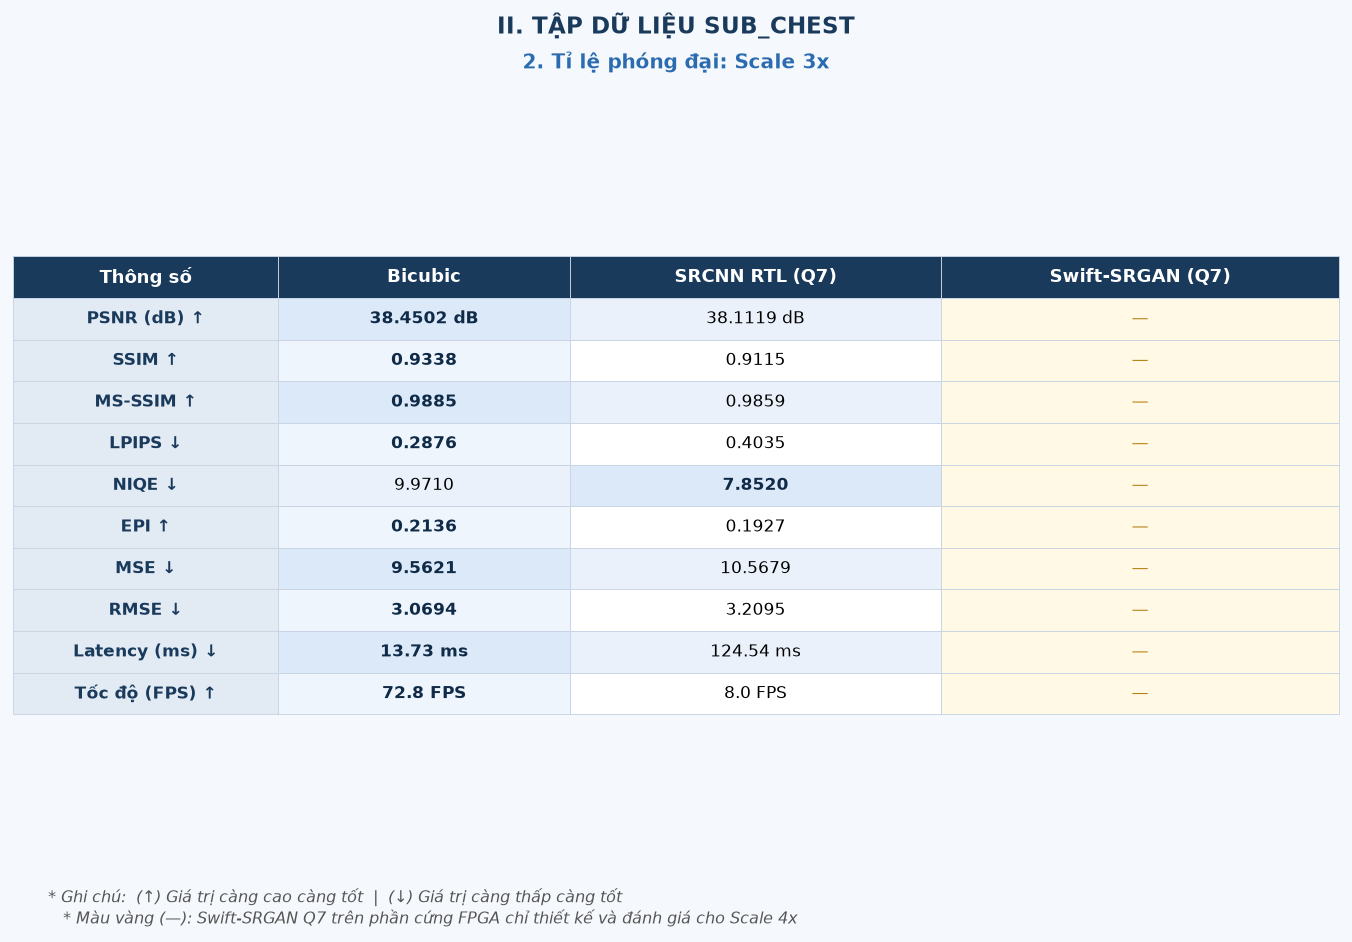

  Saved: /Users/giabao/Desktop/GitHub/AI-Based-Image-Super-Resolution/notebooks/analysis/output/nb2_sub_chest_scale3x.png


In [6]:
# ── Mục II.2: sub_chest | Scale 3x ──────────────────────────
scale = 3
ds    = 'sub_chest'
ds_label = 'sub_chest (450 ảnh)'

# Load data
model_data = {
    'Bicubic':          load_bicubic(scale),
    'SRCNN RTL (Q7)':   load_software('SRCNN', scale),
    'Swift-SRGAN (Q7)': load_swift_srgan(scale),
}

MODELS_NB2 = ['Bicubic', 'SRCNN RTL (Q7)', 'Swift-SRGAN (Q7)']
col_labels, rows = build_transposed_table(MODELS_NB2, model_data, ds)

title    = "II. TẬP DỮ LIỆU SUB_CHEST"
subtitle = "2. Tỉ lệ phóng đại: Scale 3x"
out_png  = str(OUT_DIR / f"nb2_{ds}_scale3x.png")

render_table(title, subtitle, col_labels, rows, out_png, pending_models={'Swift-SRGAN (Q7)'})


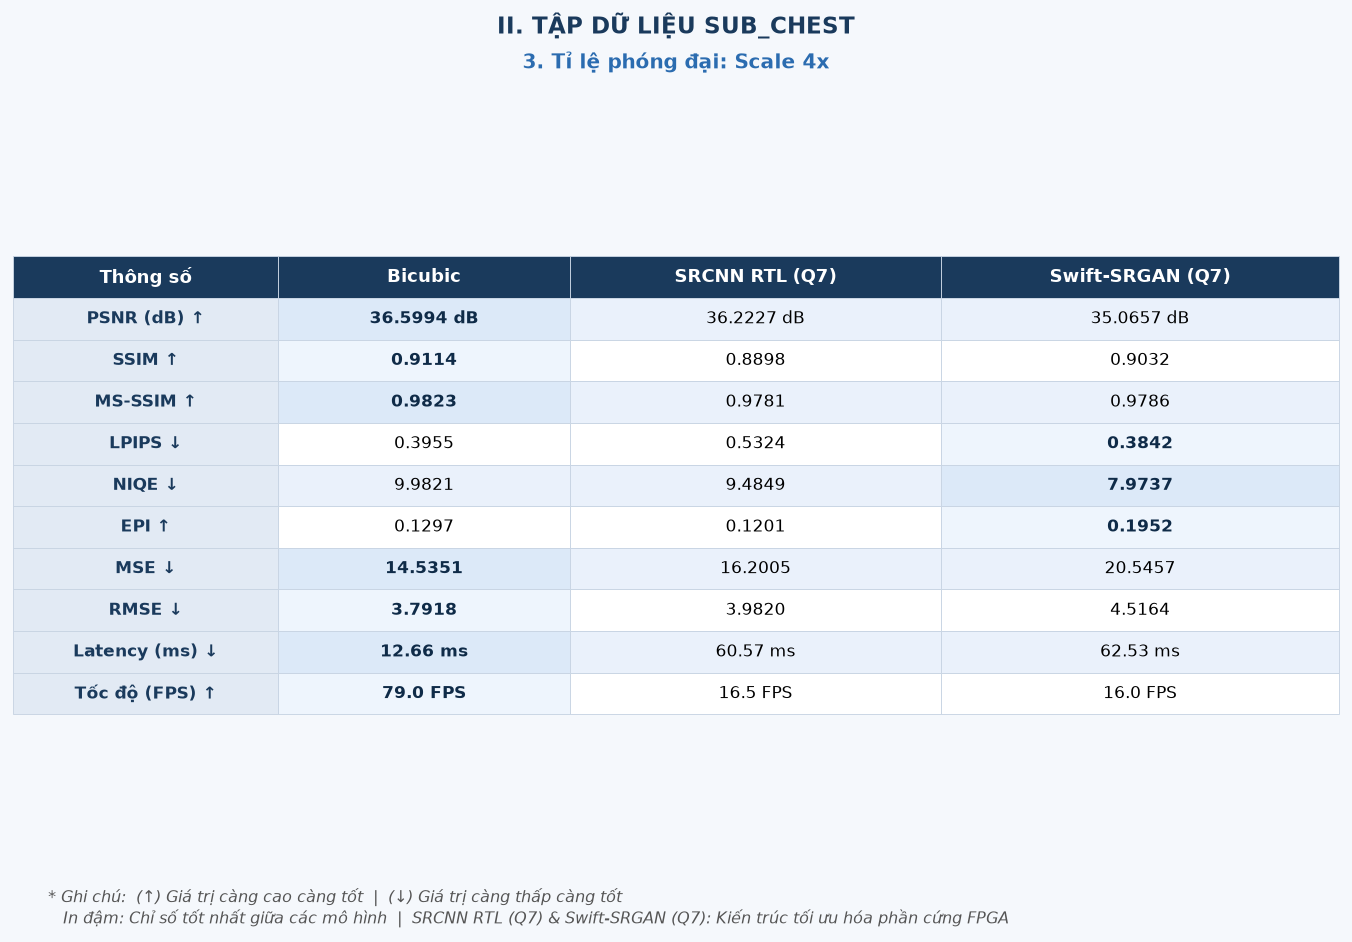

  Saved: /Users/giabao/Desktop/GitHub/AI-Based-Image-Super-Resolution/notebooks/analysis/output/nb2_sub_chest_scale4x.png


In [7]:
# ── Mục II.3: sub_chest | Scale 4x ──────────────────────────
scale = 4
ds    = 'sub_chest'
ds_label = 'sub_chest (450 ảnh)'

# Load data
model_data = {
    'Bicubic':          load_bicubic(scale),
    'SRCNN RTL (Q7)':   load_software('SRCNN', scale),
    'Swift-SRGAN (Q7)': load_swift_srgan(scale),
}

MODELS_NB2 = ['Bicubic', 'SRCNN RTL (Q7)', 'Swift-SRGAN (Q7)']
col_labels, rows = build_transposed_table(MODELS_NB2, model_data, ds)

title    = "II. TẬP DỮ LIỆU SUB_CHEST"
subtitle = "3. Tỉ lệ phóng đại: Scale 4x"
out_png  = str(OUT_DIR / f"nb2_{ds}_scale4x.png")

render_table(title, subtitle, col_labels, rows, out_png, pending_models=set())


---

## Xuất Báo Cáo PDF

Chạy cell bên dưới để xuất toàn bộ các biểu đồ so sánh thành file PDF (So Sánh Hiệu Năng: Bicubic - SRCNN RTL (Q7) - Swift-SRGAN (Q7)):
- **Trang 1:** Trang bìa và Mục lục cấu trúc báo cáo
- **Trang 2 - 4:** Mục I. Tập dữ liệu sub_NIH (Scale 2x, 3x, 4x)
- **Trang 5 - 7:** Mục II. Tập dữ liệu sub_chest (Scale 2x, 3x, 4x)


In [8]:
# Export all tables to PDF with Cover Page & TOC
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.image as mpimg

def create_cover_page():
    """Tạo trang bìa và mục lục cấu trúc báo cáo."""
    fig, ax = plt.subplots(figsize=(11.5, 7.5))
    fig.patch.set_facecolor('#f8fafd')
    ax.set_facecolor('#f8fafd')
    ax.axis('off')

    # Header title
    fig.text(0.5, 0.92, 'SO SÁNH HIỆU NĂNG BICUBIC - SRCNN RTL (Q7) - SWIFT-SRGAN (Q7)',
             ha='center', va='top', fontsize=14.5, fontweight='bold', color='#1a3a5c', fontfamily='DejaVu Sans')
    fig.text(0.5, 0.855, 'Bicubic (Baseline) vs SRCNN RTL (Q7) vs Swift-SRGAN (Q7)',
             ha='center', va='top', fontsize=11.5, style='italic', color='#2b6cb0', fontfamily='DejaVu Sans')

    # Divider line
    fig.lines.append(plt.Line2D([0.1, 0.9], [0.81, 0.81], transform=fig.transFigure, color='#1a3a5c', linewidth=1.8))

    # TOC Header
    fig.text(0.1, 0.74, 'CẤU TRÚC NỘI DUNG BÁO CÁO (MỤC LỤC):',
             ha='left', va='top', fontsize=12.5, fontweight='bold', color='#222222', fontfamily='DejaVu Sans')

    items = [
        ('sec', 'I. TẬP DỮ LIỆU SUB_NIH', None, 0.66),
        ('item', '1. Tỉ lệ phóng đại: Scale 2x', 2, 0.595),
        ('item', '2. Tỉ lệ phóng đại: Scale 3x', 3, 0.540),
        ('item', '3. Tỉ lệ phóng đại: Scale 4x', 4, 0.485),
        ('sec', 'II. TẬP DỮ LIỆU SUB_CHEST', None, 0.395),
        ('item', '1. Tỉ lệ phóng đại: Scale 2x', 5, 0.330),
        ('item', '2. Tỉ lệ phóng đại: Scale 3x', 6, 0.275),
        ('item', '3. Tỉ lệ phóng đại: Scale 4x', 7, 0.220),
    ]

    for itype, text, page, y in items:
        if itype == 'sec':
            fig.text(0.10, y, text, ha='left', va='center', fontsize=11.5, fontweight='bold', color='#1a3a5c', fontfamily='DejaVu Sans')
        else:
            fig.text(0.14, y, text, ha='left', va='center', fontsize=11.0, color='#333333', fontfamily='DejaVu Sans')
            fig.lines.append(plt.Line2D([0.45, 0.81], [y, y], transform=fig.transFigure, color='#bbbbbb', linestyle=':', linewidth=1.2))
            fig.text(0.86, y, f'Trang {page}', ha='right', va='center', fontsize=11.0, fontweight='bold', color='#1a3a5c', fontfamily='DejaVu Sans')

    # Footer
    fig.text(0.5, 0.05, 'AI-Based Image Super-Resolution for Medical Imaging',
             ha='center', va='bottom', fontsize=9.5, style='italic', color='#777777', fontfamily='DejaVu Sans')
    return fig

ordered_charts = [
    OUT_DIR / 'nb2_sub_NIH_scale2x.png',
    OUT_DIR / 'nb2_sub_NIH_scale3x.png',
    OUT_DIR / 'nb2_sub_NIH_scale4x.png',
    OUT_DIR / 'nb2_sub_chest_scale2x.png',
    OUT_DIR / 'nb2_sub_chest_scale3x.png',
    OUT_DIR / 'nb2_sub_chest_scale4x.png',
]

pdf_path = str(OUT_DIR / 'so_sanh_hieu_nang_bicubic-srcnn-swiftSrgan.pdf')

with PdfPages(pdf_path) as pdf:
        # Trang bìa & Mục lục
    fig_cover = create_cover_page()
    pdf.savefig(fig_cover, bbox_inches='tight', dpi=130)
    plt.close(fig_cover)
        
        # Các trang biểu đồ theo thứ tự I.1, I.2, I.3, II.1, II.2, II.3
    for png_path in ordered_charts:
        if png_path.exists():
            img = mpimg.imread(str(png_path))
            fig, ax = plt.subplots(figsize=(11.5, img.shape[0] / img.shape[1] * 11.5))
            ax.imshow(img)
            ax.axis('off')
            pdf.savefig(fig, bbox_inches='tight', dpi=130)
            plt.close(fig)
    
print(f'✓ Xuất PDF thành công (7 trang): {pdf_path}')
from IPython.display import FileLink
display(FileLink(pdf_path))


✓ Xuất PDF thành công (7 trang): /Users/giabao/Desktop/GitHub/AI-Based-Image-Super-Resolution/notebooks/analysis/output/so_sanh_hieu_nang_bicubic-srcnn-swiftSrgan.pdf


/Users/giabao/Desktop/GitHub/AI-Based-Image-Super-Resolution/notebooks/analysis/output/so_sanh_hieu_nang_bicubic-srcnn-swiftSrgan.pdf